# Telugu ↔ English Translation with Sarvam-Translate

Uses the `sarvamai/sarvam-translate` model from Hugging Face to translate between Telugu and English.

Model card: https://huggingface.co/sarvamai/sarvam-translate

In [ ]:
%pip install -q transformers accelerate torch

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "sarvamai/sarvam-translate"

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=dtype,
    low_cpu_mem_usage=True,
).to(device)

/home/ramesh/IASNLP/SiLLM/MT_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 16.33it/s]


In [2]:
def translate(input_txt: str, tgt_lang: str) -> str:
    messages = [
        {"role": "system", "content": f"Translate the text below to {tgt_lang}."},
        {"role": "user", "content": input_txt},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=1024,
        do_sample=True,
        temperature=0.01,
        num_return_sequences=1,
    )
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
    return tokenizer.decode(output_ids, skip_special_tokens=True)

## Telugu → English

In [3]:
telugu_sentence = "నేను రోజూ ఉదయం పార్కులో నడుస్తాను."

english_translation = translate(telugu_sentence, "English")

print("Input (Telugu):", telugu_sentence)
print("Translation (English):", english_translation)

Input (Telugu): నేను రోజూ ఉదయం పార్కులో నడుస్తాను.
Translation (English): I walk in the park every morning.


## English → Telugu

In [6]:
english_sentence = "Be the change you wish to see in the world."

telugu_translation = translate(english_sentence, "Telugu")

print("Input (English):", english_sentence)
print("Translation (Telugu):", telugu_translation)

Input (English): Be the change you wish to see in the world.
Translation (Telugu): ప్రపంచంలో మీరు చూడాలనుకుంటున్న మార్పు మీరే అవ్వండి.


# BLEU Evaluation on IN22-Conv and IN22-Gen (Telugu → English)

Establishes a quality baseline for `sarvam-translate` before building a simultaneous MT system.
Datasets are local Te→En pairs (`input` = Telugu source, `reference` = English reference).
BLEU is computed with **sacrebleu** (corpus-level, the standard for MT reporting).

In [6]:
%pip install -q sacrebleu

import json
import sacrebleu
from tqdm.auto import tqdm

# Decoder-only models need left padding so generated tokens are contiguous.
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def load_pairs(path):
    """Load IN22 json -> (sources, references)."""
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    sources = [d["input"] for d in data]
    references = [d["reference"] for d in data]
    return sources, references


@torch.inference_mode()
def translate_batch(sentences, tgt_lang, batch_size=16, max_new_tokens=256):
    """Translate a list of sentences to tgt_lang in batches."""
    outputs = []
    for start in tqdm(range(0, len(sentences), batch_size)):
        batch = sentences[start:start + batch_size]
        texts = [
            tokenizer.apply_chat_template(
                [
                    {"role": "system", "content": f"Translate the text below to {tgt_lang}."},
                    {"role": "user", "content": s},
                ],
                tokenize=False,
                add_generation_prompt=True,
            )
            for s in batch
        ]
        model_inputs = tokenizer(
            texts, return_tensors="pt", padding=True, truncation=True
        ).to(model.device)

        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # greedy -> deterministic, reproducible BLEU
            num_beams=1,
            pad_token_id=tokenizer.pad_token_id,
        )
        # Strip the prompt prefix from each sequence.
        gen_only = generated_ids[:, model_inputs.input_ids.shape[1]:]
        decoded = tokenizer.batch_decode(gen_only, skip_special_tokens=True)
        outputs.extend(t.strip() for t in decoded)
    return outputs


def evaluate(path, tgt_lang="English", batch_size=4):
    sources, references = load_pairs(path)
    hypotheses = translate_batch(sources, tgt_lang, batch_size=batch_size)
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    return bleu, hypotheses, references


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
# IN22-Conv (Telugu -> English)
conv_bleu, conv_hyps, conv_refs = evaluate("in22_conv_te_en.json", tgt_lang="English")
print("IN22-Conv  Te->En:", conv_bleu.score)
print(conv_bleu)

  0%|          | 0/376 [00:00<?, ?it/s]Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
100%|██████████| 376/376 [06:52<00:00,  1.10s/it]

IN22-Conv  Te->En: 26.70149979234695
BLEU = 26.70 58.7/32.7/20.8/13.3 (BP = 0.989 ratio = 0.990 hyp_len = 17008 ref_len = 17188)


In [9]:
# IN22-Gen (Telugu -> English)
gen_bleu, gen_hyps, gen_refs = evaluate("in22_gen_te_en.json", tgt_lang="English")
print("IN22-Gen   Te->En:", gen_bleu.score)
print(gen_bleu)

100%|██████████| 256/256 [12:56<00:00,  3.03s/it]


IN22-Gen   Te->En: 29.117401501175955
BLEU = 29.12 61.8/35.2/23.2/16.2 (BP = 0.969 ratio = 0.969 hyp_len = 28324 ref_len = 29219)


In [10]:
# Summary + a few qualitative examples
print(f"{'Dataset':<14}{'BLEU':>8}")
print(f"{'IN22-Conv':<14}{conv_bleu.score:>8.2f}")
print(f"{'IN22-Gen':<14}{gen_bleu.score:>8.2f}")

print("\n--- Sample translations (IN22-Conv) ---")
conv_src, _ = load_pairs("in22_conv_te_en.json")
for i in range(3):
    print(f"\nSRC : {conv_src[i]}")
    print(f"HYP : {conv_hyps[i]}")
    print(f"REF : {conv_refs[i]}")

Dataset           BLEU
IN22-Conv        26.70
IN22-Gen         29.12

--- Sample translations (IN22-Conv) ---

SRC : అమ్మా, రేపు సినిమాకి వెళ్దాం.
HYP : Mom, let's go to the movies tomorrow.
REF : Mom, let's go for a movie tomorrow.

SRC : నేను స్కూల్ వెళ్లనవసరం లేదు.
HYP : I don't need to go to school.
REF : I don't have to go to school.

SRC : రేపు సెలవు.
HYP : Tomorrow is a holiday.
REF : It is a holiday.


In [ ]:
# Save translations and BLEU scores to files
import json


def save_results(name, path, bleu, hyps, refs):
    sources, _ = load_pairs(path)

    # Per-sentence outputs (source / hypothesis / reference) as JSON.
    records = [
        {"input": s, "hypothesis": h, "reference": r}
        for s, h, r in zip(sources, hyps, refs)
    ]
    with open(f"{name}_outputs.json", "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)


    print(f"Saved {name}_outputs.json and {name}_hyp.txt ({len(hyps)} sentences)")


save_results("in22_conv_te_en", "in22_conv_te_en.json", conv_bleu, conv_hyps, conv_refs)
save_results("in22_gen_te_en", "in22_gen_te_en.json", gen_bleu, gen_hyps, gen_refs)

# Combined BLEU summary.
summary = {
    "model": model_name,
    "direction": "Telugu -> English",
    "decoding": "greedy",
    "results": {
        "IN22-Conv": {"bleu": conv_bleu.score, "signature": str(conv_bleu)},
        "IN22-Gen": {"bleu": gen_bleu.score, "signature": str(gen_bleu)},
    },
}
with open("bleu_scores.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("Saved bleu_scores.json")

Saved in22_conv_te_en_outputs.json and in22_conv_te_en_hyp.txt (1503 sentences)
Saved in22_gen_te_en_outputs.json and in22_gen_te_en_hyp.txt (1024 sentences)
Saved bleu_scores.json


# Wait-k Policy Decoding (single example)

A demonstration of the **wait-k** simultaneous-translation policy (Ma et al., 2019) on one Telugu→English sentence.

The policy:
1. **READ** the first `k` source words before writing anything.
2. To produce target token `t` (1-indexed), the model may see source words up to position `k + t − 1` (capped at the full source).
3. **WRITE** one target token per step; once committed, a token is **never revised** — the defining constraint of simultaneous MT.

`sarvam-translate` is a standard full-sentence model, so we *simulate* streaming by re-prompting it with a growing source prefix at each step and reading off only the next token. EOS is suppressed until the whole source has been read, so the model cannot finish before consuming the input.

In [4]:
import torch

EOS_IDS = [tokenizer.eos_token_id]
# Some chat models stop on extra tokens (e.g. <|im_end|>); include them if present.
for tok in ["<|im_end|>", "<end_of_turn>"]:
    tid = tokenizer.convert_tokens_to_ids(tok)
    if tid is not None and tid != tokenizer.unk_token_id:
        EOS_IDS.append(tid)


@torch.inference_mode()
def wait_k_decode(source, k=3, tgt_lang="English", max_target_tokens=128, verbose=True):
    """Simulate wait-k simultaneous decoding for one sentence.

    Returns the committed translation and a READ/WRITE action trace.
    """
    src_words = source.split()
    S = len(src_words)

    committed_ids = []   # target token ids written so far
    trace = []           # list of (action, detail) for printing
    prev_read = 0

    for t in range(1, max_target_tokens + 1):
        # Wait-k: target token t may see source words up to (k + t - 1).
        num_src = min(k + t - 1, S)

        # Log the READ steps that happened before this WRITE.
        while prev_read < num_src:
            prev_read += 1
            trace.append(("READ", src_words[prev_read - 1]))

        # Build the prompt from the current source prefix + committed target.
        src_prefix = " ".join(src_words[:num_src])
        prompt = tokenizer.apply_chat_template(
            [
                {"role": "system", "content": f"Translate the text below to {tgt_lang}."},
                {"role": "user", "content": src_prefix},
            ],
            tokenize=False,
            add_generation_prompt=True,
        )
        prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)
        input_ids = torch.cat(
            [prompt_ids, torch.tensor([committed_ids], device=model.device, dtype=prompt_ids.dtype)],
            dim=1,
        ) if committed_ids else prompt_ids

        logits = model(input_ids=input_ids).logits[0, -1]

        # Suppress EOS until the entire source has been read (can't finish early).
        if num_src < S:
            for eid in EOS_IDS:
                logits[eid] = float("-inf")

        next_id = int(logits.argmax())

        if next_id in EOS_IDS:
            trace.append(("STOP", "<eos>"))
            break

        committed_ids.append(next_id)
        piece = tokenizer.decode([next_id], skip_special_tokens=True)
        trace.append(("WRITE", piece))

    translation = tokenizer.decode(committed_ids, skip_special_tokens=True).strip()

    if verbose:
        print(f"Source   : {source}")
        print(f"Policy   : wait-{k}  (source words = {S})\n")
        read_buf, tgt_buf = [], ""
        for action, detail in trace:
            if action == "READ":
                read_buf.append(detail)
                print(f"  READ  -> [{' '.join(read_buf)}]")
            elif action == "WRITE":
                tgt_buf += detail
                print(f"  WRITE -> '{detail}'   (target so far:{tgt_buf})")
            else:
                print(f"  {action}")
        print(f"\nFinal translation: {translation}")

    return translation, trace


_ = wait_k_decode("నేను రోజూ ఉదయం పార్కులో నడుస్తాను.", k=2)

Source   : నేను రోజూ ఉదయం పార్కులో నడుస్తాను.
Policy   : wait-2  (source words = 5)

  READ  -> [నేను]
  READ  -> [నేను రోజూ]
  WRITE -> 'I'   (target so far:I)
  READ  -> [నేను రోజూ ఉదయం]
  WRITE -> ' wake'   (target so far:I wake)
  READ  -> [నేను రోజూ ఉదయం పార్కులో]
  WRITE -> ' up'   (target so far:I wake up)
  READ  -> [నేను రోజూ ఉదయం పార్కులో నడుస్తాను.]
  WRITE -> ' and'   (target so far:I wake up and)
  WRITE -> ' walk'   (target so far:I wake up and walk)
  WRITE -> ' in'   (target so far:I wake up and walk in)
  WRITE -> ' the'   (target so far:I wake up and walk in the)
  WRITE -> ' park'   (target so far:I wake up and walk in the park)
  WRITE -> ' every'   (target so far:I wake up and walk in the park every)
  WRITE -> ' morning'   (target so far:I wake up and walk in the park every morning)
  WRITE -> '.'   (target so far:I wake up and walk in the park every morning.)
  STOP

Final translation: I wake up and walk in the park every morning.


# BLEU: Full-sentence vs Wait-k (different k)

Quantifies the quality cost of committing early. We decode the same set of sentences with:
- **Full-sentence** (offline) decoding — the upper bound, the model sees everything.
- **Wait-k** for several `k` — the model commits each token after seeing only `k + t − 1` source words.

Smaller `k` → lower latency but lower BLEU; larger `k` → approaches the full-sentence score.
We also report **Average Lagging (AL)**, the standard simultaneous-MT latency metric (lower = faster, more simultaneous).

> Wait-k here is unbatched and uncached (one forward pass per token), so we evaluate on a subset. Increase `N_SUBSET` for a more reliable curve at the cost of time.

In [5]:
N_SUBSET = None                 # number of sentences to evaluate on
K_VALUES = [1, 3, 5, 7]        # wait-k policies to compare
EVAL_FILE = "in22_conv_te_en.json"


def average_lagging(trace, num_src_words):
    """Average Lagging (Ma et al., 2019) from a READ/WRITE action trace.

    AL = (1/tau) * sum_t [ g(t) - (t-1) / (target_len / src_len) ]
    where g(t) = #source words read when target token t is written,
    and tau is the first target step at which the full source is consumed.
    """
    src_read, g = 0, []          # g[t] = source words available at write t
    for action, _ in trace:
        if action == "READ":
            src_read += 1
        elif action == "WRITE":
            g.append(src_read)
    if not g:
        return float("nan")
    tgt_len, src_len = len(g), num_src_words
    rate = tgt_len / src_len
    # tau: first write step (1-indexed) where the whole source has been read.
    tau = next((i + 1 for i, gv in enumerate(g) if gv >= src_len), tgt_len)
    al = sum(g[t] - t / rate for t in range(tau)) / tau
    return al


# --- Subset ---
src_all, ref_all = load_pairs(EVAL_FILE)
src_sub, ref_sub = src_all[:N_SUBSET], ref_all[:N_SUBSET]

results = []

# --- Full-sentence baseline on the same subset (greedy) ---
full_hyps = translate_batch(src_sub, "English", batch_size=8)
full_bleu = sacrebleu.corpus_bleu(full_hyps, [ref_sub]).score
results.append({"policy": "full-sentence", "k": None, "bleu": full_bleu, "AL": float("nan")})
print(f"full-sentence  BLEU={full_bleu:.2f}")

# --- Wait-k for each k ---
for k in K_VALUES:
    hyps, als = [], []
    for src in tqdm(src_sub, desc=f"wait-{k}"):
        hyp, trace = wait_k_decode(src, k=k, verbose=False)
        hyps.append(hyp)
        als.append(average_lagging(trace, len(src.split())))
    bleu = sacrebleu.corpus_bleu(hyps, [ref_sub]).score
    mean_al = sum(als) / len(als)
    results.append({"policy": f"wait-{k}", "k": k, "bleu": bleu, "AL": mean_al})
    print(f"wait-{k:<2}        BLEU={bleu:.2f}   AL={mean_al:.2f}")

NameError: name 'load_pairs' is not defined

Policy              BLEU      AL   Δ vs full
--------------------------------------------
full-sentence      24.65     -              
wait-1             21.23    1.71       -3.42
wait-3             22.30    3.10       -2.34
wait-5             23.30    3.85       -1.35
wait-7             24.65    4.00       +0.00

Saved waitk_vs_full_bleu.json


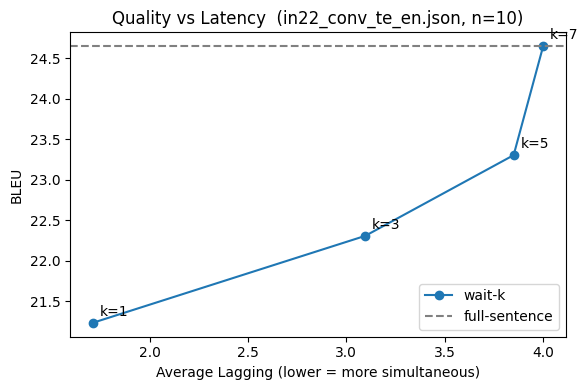

Saved waitk_quality_latency.png


In [14]:
import json

# --- Results table ---
print(f"{'Policy':<16}{'BLEU':>8}{'AL':>8}{'Δ vs full':>12}")
print("-" * 44)
for r in results:
    al = "  -  " if r["AL"] != r["AL"] else f"{r['AL']:.2f}"   # NaN check
    delta = "" if r["policy"] == "full-sentence" else f"{r['bleu'] - full_bleu:+.2f}"
    print(f"{r['policy']:<16}{r['bleu']:>8.2f}{al:>8}{delta:>12}")

# --- Save ---
with open("waitk_vs_full_bleu.json", "w", encoding="utf-8") as f:
    json.dump({"eval_file": EVAL_FILE, "n_subset": N_SUBSET, "results": results}, f, indent=2)
print("\nSaved waitk_vs_full_bleu.json")

# --- Quality vs latency plot ---
try:
    import matplotlib.pyplot as plt

    wk = [r for r in results if r["k"] is not None]
    plt.figure(figsize=(6, 4))
    plt.plot([r["AL"] for r in wk], [r["bleu"] for r in wk], "o-", label="wait-k")
    for r in wk:
        plt.annotate(f"k={r['k']}", (r["AL"], r["bleu"]),
                     textcoords="offset points", xytext=(5, 5))
    plt.axhline(full_bleu, ls="--", color="gray", label="full-sentence")
    plt.xlabel("Average Lagging (lower = more simultaneous)")
    plt.ylabel("BLEU")
    plt.title(f"Quality vs Latency  ({EVAL_FILE}, n={N_SUBSET})")
    plt.legend()
    plt.tight_layout()
    plt.savefig("waitk_quality_latency.png", dpi=120)
    plt.show()
    print("Saved waitk_quality_latency.png")
except ImportError:
    print("matplotlib not installed; skipping plot (pip install matplotlib)")